In [1]:
# Notebook 02: PCA Analysis
#
# Purpose:
# - Load merged county-level modeling data
# - Select PCA variables
# - Align feature direction for risk
# - Handle missing values
# - Standardize variables
# - Run PCA
# - Create county-level composite risk scores

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [3]:
BASE_DIR = Path.cwd().parent
model_file = BASE_DIR / "data" / "merged" / "gc_cpri_model_input.csv"

df = pd.read_csv(model_file)
df.head()

,county,registered_voters,total_ballots_cast,turnout_rate,absentee_rate,population_2023,poverty_rate,pct_less_hs,pct_bachelors,unemployment_rate,median_income,non_white_share,rural_urban_code,broadband_access_rate
0,BALDWIN,207643,122542,0.5902,0.0634,243176.00,10.0,8.268600,32.797637,3.400,71704.0,0.082985,3.0,0.91
1,CLARKE,19143,11993,0.6265,0.0604,22659.50,19.0,14.731304,15.426531,6.350,44906.0,0.413350,9.0,0.74
2,CONECUH,9820,6105,0.6217,0.0785,11318.00,26.5,12.513843,13.129076,4.875,36106.0,0.431829,9.0,0.73
3,ESCAMBIA,28268,15009,0.5310,0.0477,36634.75,21.3,17.467352,12.490686,4.200,47792.0,0.271598,6.0,0.79
4,MOBILE,322535,176019,0.5457,0.0489,412699.50,16.3,10.991693,25.150224,4.850,54315.0,0.355915,2.0,0.86


In [4]:
candidate_features = [
    "poverty_rate",
    "unemployment_rate",
    "median_income",
    "pct_less_hs",
    "non_white_share",
    "rural_urban_code",
    "broadband_access_rate"
]

pca_df = df[candidate_features].copy()
pca_df.head()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code,broadband_access_rate
0,10.0,3.400,71704.0,8.268600,0.082985,3.0,0.91
1,19.0,6.350,44906.0,14.731304,0.413350,9.0,0.74
2,26.5,4.875,36106.0,12.513843,0.431829,9.0,0.73
3,21.3,4.200,47792.0,17.467352,0.271598,6.0,0.79
4,16.3,4.850,54315.0,10.991693,0.355915,2.0,0.86


In [5]:
pca_df.describe()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code,broadband_access_rate
count,7.00000,7.000000,7.000000,7.000000,8.000000,7.000000,7.000000
mean,18.70000,4.885714,50872.285714,13.096151,0.307679,6.428571,0.801429
std,4.98832,0.949326,11021.269054,3.262040,0.114484,2.878492,0.064918
min,10.00000,3.400000,36106.000000,8.268600,0.082985,2.000000,0.730000
25%,17.50000,4.525000,46202.000000,11.153325,0.261054,4.500000,0.755000
50%,19.00000,4.875000,47792.000000,12.513843,0.313756,8.000000,0.790000
75%,20.20000,5.262500,54050.000000,15.558307,0.393782,8.500000,0.835000
max,26.50000,6.350000,71704.000000,17.467352,0.431829,9.000000,0.910000


In [6]:
# poverty: higher poverty = higher risk
if pca_df["poverty_rate"].max() > 1:
    pca_df["poverty_rate"] = pca_df["poverty_rate"] / 100

# unemployment: higher unemployment = higher risk
if pca_df["unemployment_rate"].max() > 1:
    pca_df["unemployment_rate"] = pca_df["unemployment_rate"] / 100

# education: higher % less than HS = higher risk
if pca_df["pct_less_hs"].max() > 1:
    pca_df["pct_less_hs"] = pca_df["pct_less_hs"] / 100

# income: higher income = lower risk
pca_df["median_income"] = -1 * pca_df["median_income"]

# rural: higher = more rural = higher risk
pca_df["rural_urban_code"] = pca_df["rural_urban_code"]

# broadband: higher = less access = higher risk
pca_df["broadband_access_rate"] = 1 - pca_df["broadband_access_rate"]

pca_df.head()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code,broadband_access_rate
0,0.100,0.03400,-71704.0,0.082686,0.082985,3.0,0.09
1,0.190,0.06350,-44906.0,0.147313,0.413350,9.0,0.26
2,0.265,0.04875,-36106.0,0.125138,0.431829,9.0,0.27
3,0.213,0.04200,-47792.0,0.174674,0.271598,6.0,0.21
4,0.163,0.04850,-54315.0,0.109917,0.355915,2.0,0.14


In [7]:
pca_df.isna().sum()

poverty_rate             1
unemployment_rate        1
median_income            1
pct_less_hs              1
non_white_share          0
rural_urban_code         1
broadband_access_rate    1
dtype: int64

In [8]:
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(pca_df),
    columns=pca_df.columns
)

X_imputed.head()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code,broadband_access_rate
0,0.100,0.03400,-71704.0,0.082686,0.082985,3.0,0.09
1,0.190,0.06350,-44906.0,0.147313,0.413350,9.0,0.26
2,0.265,0.04875,-36106.0,0.125138,0.431829,9.0,0.27
3,0.213,0.04200,-47792.0,0.174674,0.271598,6.0,0.21
4,0.163,0.04850,-54315.0,0.109917,0.355915,2.0,0.14


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [10]:
corr = X_imputed.corr()
corr

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code,broadband_access_rate
poverty_rate,1.000000,0.418253,0.954210,0.567266,0.746545,0.695371,0.875826
unemployment_rate,0.418253,1.000000,0.635478,0.493408,0.812254,0.624126,0.725164
median_income,0.954210,0.635478,1.000000,0.630751,0.869371,0.734473,0.943300
pct_less_hs,0.567266,0.493408,0.630751,1.000000,0.538591,0.490163,0.680835
non_white_share,0.746545,0.812254,0.869371,0.538591,1.000000,0.520737,0.806896
rural_urban_code,0.695371,0.624126,0.734473,0.490163,0.520737,1.000000,0.888596
broadband_access_rate,0.875826,0.725164,0.943300,0.680835,0.806896,0.888596,1.000000


In [11]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [12]:
explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.748422,0.748422
1,PC2,0.096142,0.844564
2,PC3,0.078565,0.923129
3,PC4,0.071421,0.994550
4,PC5,0.002663,0.997213
5,PC6,0.002219,0.999432
6,PC7,0.000568,1.000000


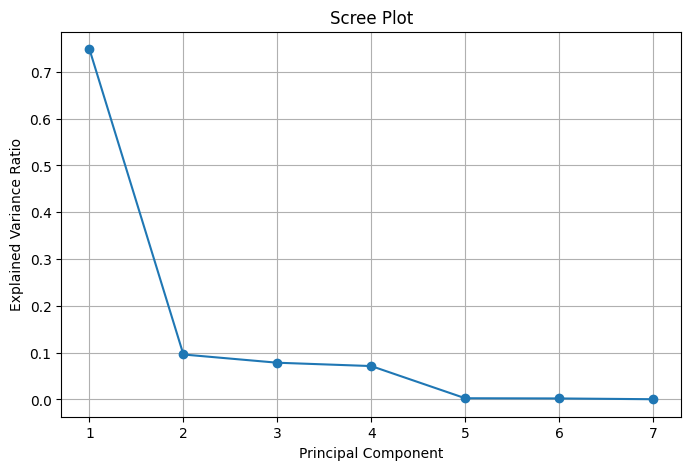

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

In [14]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_imputed.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
poverty_rate,0.385532,-0.485190,-0.130476,-0.308674,-0.032244,-0.578422,0.409928
unemployment_rate,0.337781,0.756005,-0.053397,0.155253,0.346041,-0.307448,0.270438
median_income,0.420880,-0.184813,-0.086377,-0.264393,0.665435,0.229904,-0.464413
pct_less_hs,0.313049,-0.098096,0.912764,0.208534,-0.052430,-0.080534,-0.080736
non_white_share,0.384726,0.345175,-0.031218,-0.522931,-0.598443,0.067019,-0.309488
rural_urban_code,0.359497,-0.146703,-0.360814,0.684917,-0.251792,-0.184252,-0.390634
broadband_access_rate,0.429974,-0.092735,-0.091458,0.157030,-0.110136,0.687839,0.536887


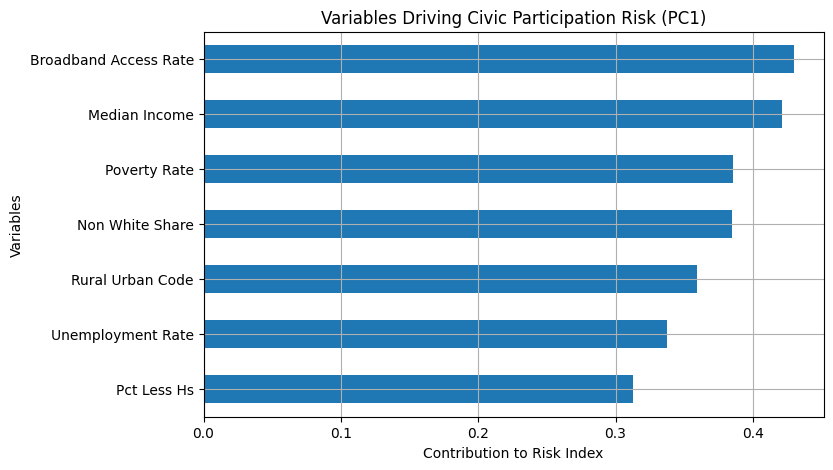

In [15]:
# PC1 Loadings Bar Chart

plt.figure(figsize=(8, 5))

# Format variable names
formatted_index = (
    loadings["PC1"]
    .sort_values()
    .index
    .str.replace("_", " ")     
    .str.title()              
)

# Plot using formatted labels
loadings["PC1"].sort_values().set_axis(formatted_index).plot(kind="barh")

plt.title("Variables Driving Civic Participation Risk (PC1)")
plt.xlabel("Contribution to Risk Index")
plt.ylabel("Variables")

plt.grid(True)

plt.show()

In [16]:
df["gc_cpri_score_raw"] = X_pca[:, 0]
df[["county", "gc_cpri_score_raw"]].head()

,county,gc_cpri_score_raw
0,BALDWIN,-5.003744
1,CLARKE,2.231888
2,CONECUH,2.578421
3,ESCAMBIA,0.415390
4,MOBILE,-1.561542


In [17]:
df["gc_cpri_score"] = (
    (df["gc_cpri_score_raw"] - df["gc_cpri_score_raw"].min()) /
    (df["gc_cpri_score_raw"].max() - df["gc_cpri_score_raw"].min())
) * 100

df[["county", "gc_cpri_score"]].head()

,county,gc_cpri_score
0,BALDWIN,0.000000
1,CLARKE,95.429633
2,CONECUH,100.000000
3,ESCAMBIA,71.472112
4,MOBILE,45.398668


In [18]:
df[["county", "gc_cpri_score"]].sort_values("gc_cpri_score", ascending=False).head(10)

,county,gc_cpri_score
2,CONECUH,100.000000
1,CLARKE,95.429633
5,MONROE,86.549681
3,ESCAMBIA,71.472112
7,TOTAL (ALL OF ALABAMA),68.510484
6,WASHINGTON,60.588236
4,MOBILE,45.398668
0,BALDWIN,0.000000


In [19]:
OUTPUT_DIR = BASE_DIR / "data" / "final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT_DIR / "gc_cpri_scored_counties.csv", index=False)
loadings.to_csv(OUTPUT_DIR / "gc_cpri_pca_loadings.csv")
explained_variance.to_csv(OUTPUT_DIR / "gc_cpri_explained_variance.csv", index=False)